In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, hamming_loss
)
from xgboost import XGBClassifier
import joblib


COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"  # difficulty level, not a feature
]

df_train = pd.read_csv("/content/KDDTrain+.txt", header=None, names=COLUMN_NAMES)
df_test  = pd.read_csv("/content/KDDTest+.txt",  header=None, names=COLUMN_NAMES)

print(f"Train: {len(df_train):,} записей")
print(f"Test:  {len(df_test):,} записей")

# mapping

ATTACK_MAP = {
    "normal": "normal",
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "mailbomb": "DoS",
    "apache2": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "satan": "Probe", "mscan": "Probe", "saint": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L",
    "warezclient": "R2L", "warezmaster": "R2L", "sendmail": "R2L",
    "named": "R2L", "snmpgetattack": "R2L", "snmpguess": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "worm": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "httptunnel": "U2R", "ps": "U2R",
    "sqlattack": "U2R", "xterm": "U2R",
}

df_train["attack_class"] = df_train["label"].map(ATTACK_MAP)
df_test["attack_class"]  = df_test["label"].map(ATTACK_MAP)

df_train = df_train[df_train["attack_class"].notna()].copy()
df_test  = df_test[df_test["attack_class"].notna()].copy()

print("\nРаспределение классов (train):")
print(df_train["attack_class"].value_counts())

print("\nРаспределение классов (test):")
print(df_test["attack_class"].value_counts())


# preproccessing
feature_cols = [c for c in COLUMN_NAMES
                if c not in ["label", "difficulty"]]

X_train = df_train[feature_cols].copy()
X_test  = df_test[feature_cols].copy()
y_train_raw = df_train["attack_class"]
y_test_raw  = df_test["attack_class"]

cat_cols = ["protocol_type", "service", "flag"]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([X_train[col], X_test[col]]).unique()
    le.fit(all_vals)
    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    le_dict[col] = le
le_target = LabelEncoder()
le_target.fit(["normal", "DoS", "Probe", "R2L", "U2R"])
y_train = le_target.transform(y_train_raw)
y_test  = le_target.transform(y_test_raw)

print(f"\nКлассы и их коды: {dict(zip(le_target.classes_, range(5)))}")

# normalization
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols
)

print(f"\nX_train: {X_train_scaled.shape}")
print(f"X_test:  {X_test_scaled.shape}")


# training

import time

models = {
    "Decision Tree":  DecisionTreeClassifier(random_state=42),
    "KNN":            KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest":  RandomForestClassifier(n_estimators=100,
                                             random_state=42, n_jobs=-1),
    "XGBoost":        XGBClassifier(n_estimators=100, random_state=42,
                                    eval_metric="mlogloss",
                                    verbosity=0, n_jobs=-1),
}

print("\nОбучение моделей...")
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    print(f"  {name}: {time.time()-t0:.1f}s")

print("\n" + "="*60)
print("ТАБЛИЦА 1 — Основные метрики (weighted)")
print("="*60)

table1_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    table1_results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 6),
        "Precision": round(precision_score(y_test, y_pred,
                           average="weighted", zero_division=0), 6),
        "Recall":    round(recall_score(y_test, y_pred,
                           average="weighted", zero_division=0), 6),
        "F1-Score":  round(f1_score(y_test, y_pred,
                           average="weighted", zero_division=0), 6),
    }

df_table1 = pd.DataFrame(table1_results).T
print(df_table1.to_string())



print("\n" + "="*60)
print("ТАБЛИЦА 2 — Продвинутые метрики")
print("="*60)

table2_results = {}
for name, model in models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    table2_results[name] = {
        "ROC AUC":       round(roc_auc_score(y_test, y_proba,
                               multi_class="ovr", average="weighted"), 6),
        "Log Loss":      round(log_loss(y_test, y_proba), 6),
        "Cohen Kappa":   round(cohen_kappa_score(y_test, y_pred), 6),
        "MCC":           round(matthews_corrcoef(y_test, y_pred), 6),
        "Balanced Acc":  round(balanced_accuracy_score(y_test, y_pred), 6),
        "Hamming Loss":  round(hamming_loss(y_test, y_pred), 6),
    }

df_table2 = pd.DataFrame(table2_results).T
print(df_table2.to_string())



import os
os.makedirs("/content/model", exist_ok=True)

best_name = df_table1["Accuracy"].idxmax()
best_model = models[best_name]
print(f"\n★ Лучшая модель: {best_name}")

joblib.dump(best_model, "/content/model/ddos_model_final.joblib")
joblib.dump(scaler,     "/content/model/scaler.joblib")
joblib.dump(le_target,  "/content/model/label_encoder.joblib")

print("Модель сохранена: /content/model/ddos_model_final.joblib")
print("\nСкачай файл и положи в ddos_platform/model/")
print("Готово!")

Train: 125,973 записей
Test:  22,544 записей

Распределение классов (train):
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Распределение классов (test):
attack_class
normal    9711
DoS       7458
R2L       2754
Probe     2421
U2R        200
Name: count, dtype: int64

Классы и их коды: {np.str_('DoS'): 0, np.str_('Probe'): 1, np.str_('R2L'): 2, np.str_('U2R'): 3, np.str_('normal'): 4}

X_train: (125973, 41)
X_test:  (22544, 41)

Обучение моделей...
  Decision Tree: 1.2s
  KNN: 0.0s
  Random Forest: 17.1s
  XGBoost: 11.6s

ТАБЛИЦА 1 — Основные метрики (weighted)
               Accuracy  Precision    Recall  F1-Score
Decision Tree  0.761489   0.795550  0.761489  0.719566
KNN            0.756787   0.808705  0.756787  0.713875
Random Forest  0.751730   0.815640  0.751730  0.710752
XGBoost        0.757408   0.797474  0.757408  0.710424

ТАБЛИЦА 2 — Продвинутые метрики
                ROC AUC  Log Loss  Cohen Kappa     

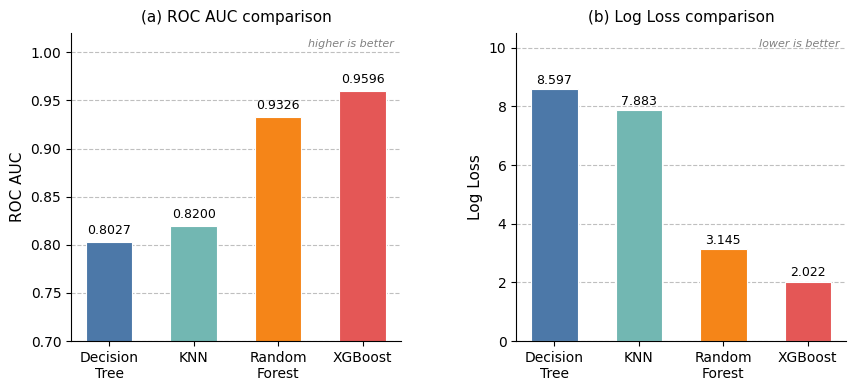

Saved: /content/figure7.png
Download: Files → /content/figure7.png → right-click → Download


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = ['Decision\nTree', 'KNN', 'Random\nForest', 'XGBoost']
roc    = [0.8027, 0.8200, 0.9326, 0.9596]
loss   = [8.597,  7.883,  3.145,  2.022]

colors = ['#4C78A8', '#72B7B2', '#F58518', '#E45756']

x = np.arange(len(models))
w = 0.55

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.35)

# ── Subplot 1: ROC AUC ────────────────────────────────────────────────────────
bars1 = ax1.bar(x, roc, width=w, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars1, roc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='normal')

ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylabel('ROC AUC', fontsize=11)
ax1.set_ylim(0.70, 1.02)
ax1.set_yticks([0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', labelsize=10)
ax1.set_title('(a) ROC AUC comparison', fontsize=11, pad=8)

# ── Subplot 2: Log Loss ───────────────────────────────────────────────────────
bars2 = ax2.bar(x, loss, width=w, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars2, loss):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='normal')

ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylabel('Log Loss', fontsize=11)
ax2.set_ylim(0, 10.5)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', labelsize=10)
ax2.set_title('(b) Log Loss comparison', fontsize=11, pad=8)

ax1.annotate('higher is better', xy=(0.98, 0.98), xycoords='axes fraction',
             fontsize=8, color='gray', ha='right', va='top', style='italic')
ax2.annotate('lower is better', xy=(0.98, 0.98), xycoords='axes fraction',
             fontsize=8, color='gray', ha='right', va='top', style='italic')

plt.savefig('/content/figure7.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved: /content/figure7.png")
print("Download: Files → /content/figure7.png → right-click → Download")